# Mathematical Engineering — Financial Engineering, FY 2025-2026

## Buy Side, Lab 4b — Risk-Based Allocation Strategies

This notebook implements and analyses risk-based allocation strategies on the Euro Stoxx 50 universe with monthly rebalancing and a 2-year rolling estimation window.

**Outline** 

0. Setup & rolling estimators
1. Part I — Equal Risk Contribution (ERC)
2. Part II — Hierarchical Risk Parity (HRP):
   1. Detoning intuition
   2. Cluster stability across rebalances (Rand index)
   3. Sensitivity to clustering choice and to the volatility allocation scheme
3. Part III — Connecting the dots: ERC vs HRP head-to-head and the role of shrinkage


## 0. Setup


In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.metrics import rand_score
from joblib import Parallel, delayed
from itertools import product

from utilities.backtest import backtest, portfolio_returns
from utilities.covariance_utilities import (
    prepare_rolling_estimation_window,
    covariance_to_correlation,
    risk_contribution,
)
from utilities.hierarchical_clustering import hierarchical_clustering
from utilities.hierarchical_risk_parity import (
    correlation_to_hrp_distance,
    dendrogram_iteration,
    hierarchical_risk_parity,
    recursive_bisection,
)
from utilities.portfolio_optimization import (
    equal_risk_contribution_portfolio,
    inverse_volatility_portfolio,
)
from utilities.principal_component_analysis import (
    detone,
    principal_component_analysis,
)
from utilities.shrinkage import constant_corr_shrinkage, market_factor_shrinkage


In [18]:
# Read prices, compute daily simple returns
data_path = Path("") # !!! COMPLETE AS APPROPRIATE !!!
last_prices = pd.read_csv(
    data_path / "sx5e_underlyings.csv", index_col="Date", parse_dates=True
)
performance = last_prices.pct_change().iloc[1:]


/var/folders/lj/p8tjbxjn385dvb0v45qf_rlr0000gn/T/ipykernel_74434/3789100018.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  performance = last_prices.pct_change().iloc[1:]


In [19]:
# Estimation parameters
estimation_window = 504  # one year of trading days
min_coverage = 0.95  # asset must have >=95% non-NaN in the window
trading_days = 252

# Rebalance on the last trading day of each month
rebalance_dates = pd.DatetimeIndex(
    performance.groupby(pd.Grouper(freq="ME"))
    .apply(lambda x: x.index[-1] if len(x) > 0 else None)
    .dropna()
    .values
)


## 1. Pre-computation: rolling covariance estimators

For each rebalance date we estimate three covariance matrices on the trailing 2-year window:

- **sample** — plain `cov()`,
- **constant_corr** — Ledoit–Wolf (2003) constant-correlation shrinkage,
- **mkt_factor** — Ledoit–Wolf (2002) single-factor shrinkage with the
  equally-weighted return of the surviving universe used as the market
  proxy.

The asset universe at every rebalance is restricted to names with
≥95% non-missing observations in the window.


In [20]:
covariances = {}  # date -> {estimator_name: cov_df}
universes = {}    # date -> [tickers]

for rebalance_date in rebalance_dates:
    cur_returns, diag = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if diag["row_count"] < estimation_window or cur_returns.shape[1] == 0:
        continue

    reb = rebalance_date.to_pydatetime().date()

    universes[reb] = list(cur_returns.columns)
    market_proxy = cur_returns.mean(axis=1)  # equally-weighted return of the surviving universe

    covariances[reb] = {
        "sample": cur_returns.cov(),
        "constant_corr": constant_corr_shrinkage(cur_returns)["shrunk_cov"],
        "mkt_factor": market_factor_shrinkage(cur_returns, market_proxy)["shrunk_cov"],
    }

all_dates = sorted(covariances.keys())

## Part I — Equal Risk Contribution (ERC)


### 1.b Sanity check: Risk contribution dispersion & IV ≡ ERC under a diagonal Σ


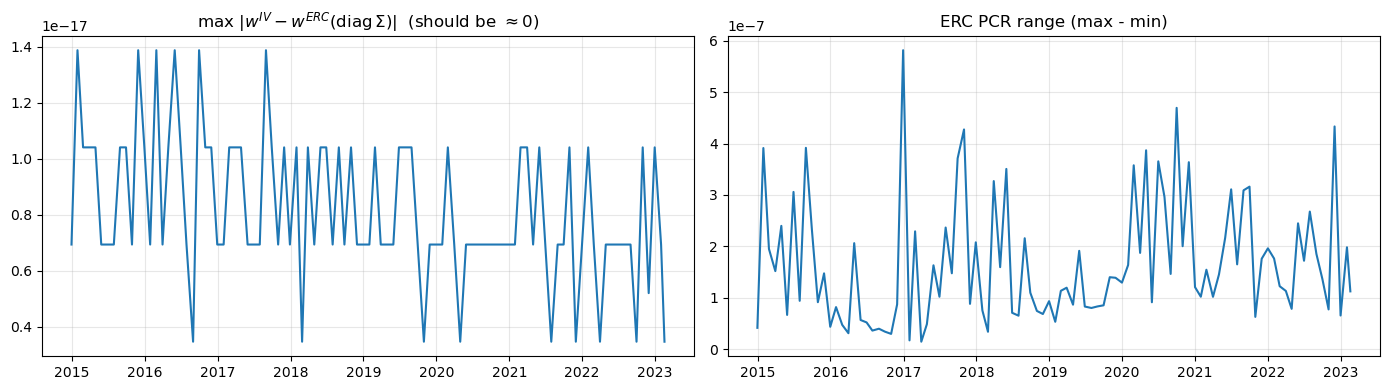

In [21]:
iv_erc_delta = {}
erc_normalized_range = {}

for date in all_dates:
    cov_arr = covariances[date]["sample"].values

    # IV vs ERC on a diagonalised Sigma — should match (Question 2 of lab notes)
    diag_cov = np.diag(np.diag(cov_arr))
    iv_w = inverse_volatility_portfolio(cov_arr)
    erc_diag_w = equal_risk_contribution_portfolio(diag_cov)
    iv_erc_delta[date] = float(np.abs(iv_w - erc_diag_w).max())

    # PCR dispersion of the ERC portfolio on the actual covariance
    erc_w = equal_risk_contribution_portfolio(cov_arr)
    rc = risk_contribution(erc_w, cov_arr)
    pcr = rc / rc.sum()
    erc_normalized_range[date] = float(pcr.max() - pcr.min())

iv_erc_delta = pd.Series(iv_erc_delta).sort_index()
erc_normalized_range = pd.Series(erc_normalized_range).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
iv_erc_delta.plot(ax=axes[0])
axes[0].set_title(r"max $|w^{IV} - w^{ERC}(\mathrm{diag}\,\Sigma)|$  (should be $\approx 0$)")
axes[0].grid(alpha=0.3)
erc_normalized_range.plot(ax=axes[1])
axes[1].set_title("ERC PCR range (max - min)")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.c ERC backtest across the three covariance estimators


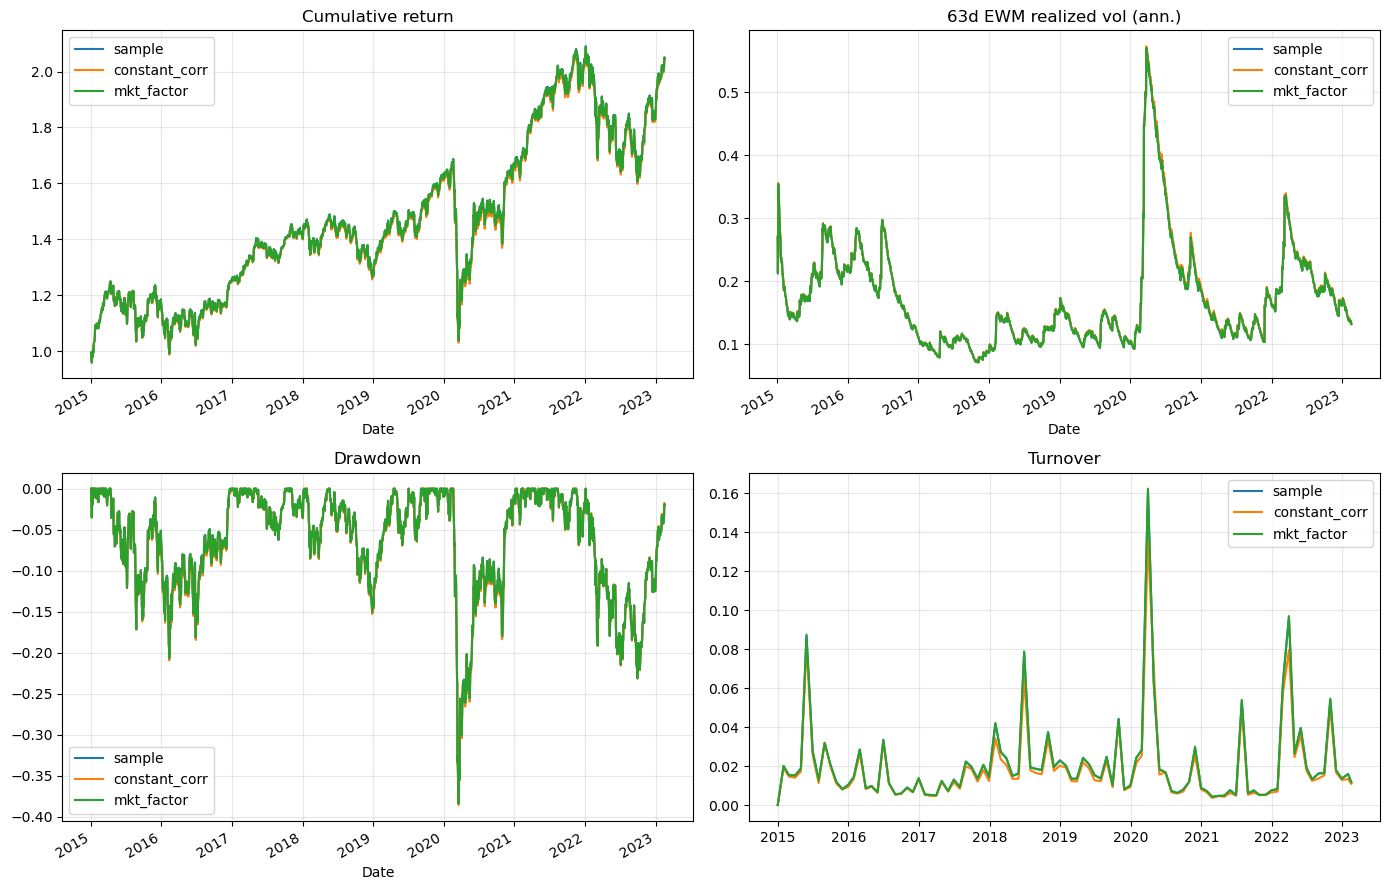

In [22]:
erc_portfolios = {"sample": {}, "constant_corr": {}, "mkt_factor": {}}

for reb in all_dates:
    for est_name, cov in covariances[reb].items():
        weights = equal_risk_contribution_portfolio(cov.values)
        erc_portfolios[est_name][reb] = pd.Series(weights, index=cov.index)

# Stack into rebalance schedules (rows = rebalance dates, cols = assets)
erc_weights_df = {
    name: pd.DataFrame.from_dict(d, orient="index").fillna(0.0)
    for name, d in erc_portfolios.items()
}

# Cumulative curves and daily returns per estimator
erc_curves   = {name: backtest(df, performance)          for name, df in erc_weights_df.items()}
erc_returns  = {name: portfolio_returns(df, performance) for name, df in erc_weights_df.items()}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Cumulative return
ax = axes[0, 0]
for name, curve in erc_curves.items():
    curve.plot(ax=ax, label=name)
ax.set_title("Cumulative return"); ax.legend(); ax.grid(alpha=0.3)

# 63d EWM realized vol, annualized
ax = axes[0, 1]
for name, ret in erc_returns.items():
    (ret.ewm(span=63).std() * np.sqrt(trading_days)).plot(ax=ax, label=name)
ax.set_title("63d EWM realized vol (ann.)"); ax.legend(); ax.grid(alpha=0.3)

# Drawdown
ax = axes[1, 0]
for name, curve in erc_curves.items():
    (curve / curve.cummax() - 1.0).plot(ax=ax, label=name)
ax.set_title("Drawdown"); ax.legend(); ax.grid(alpha=0.3)

# Turnover (L1 weight changes per rebalance)
ax = axes[1, 1]
for name, df in erc_weights_df.items():
    df.diff().abs().sum(axis=1).plot(ax=ax, label=name)
ax.set_title("Turnover"); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## Part II — Hierarchical Risk Parity (HRP)


### 2.a Detoning — intuition


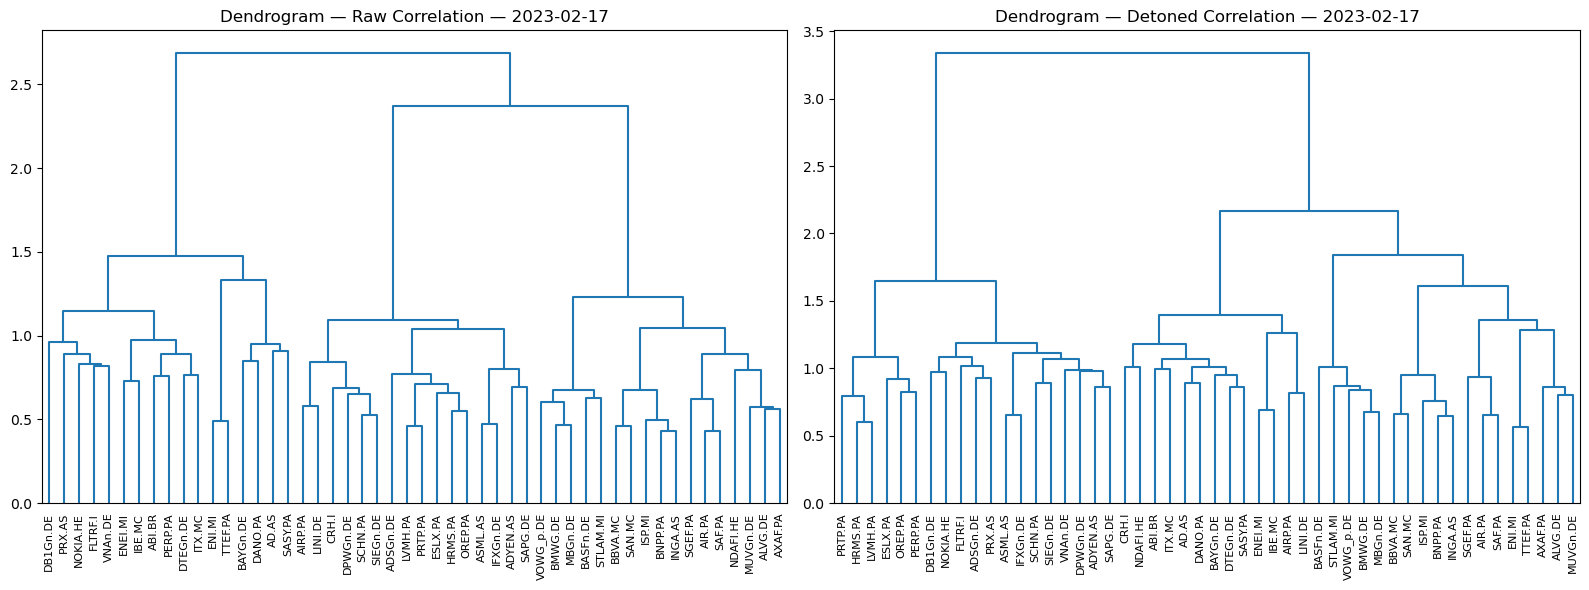

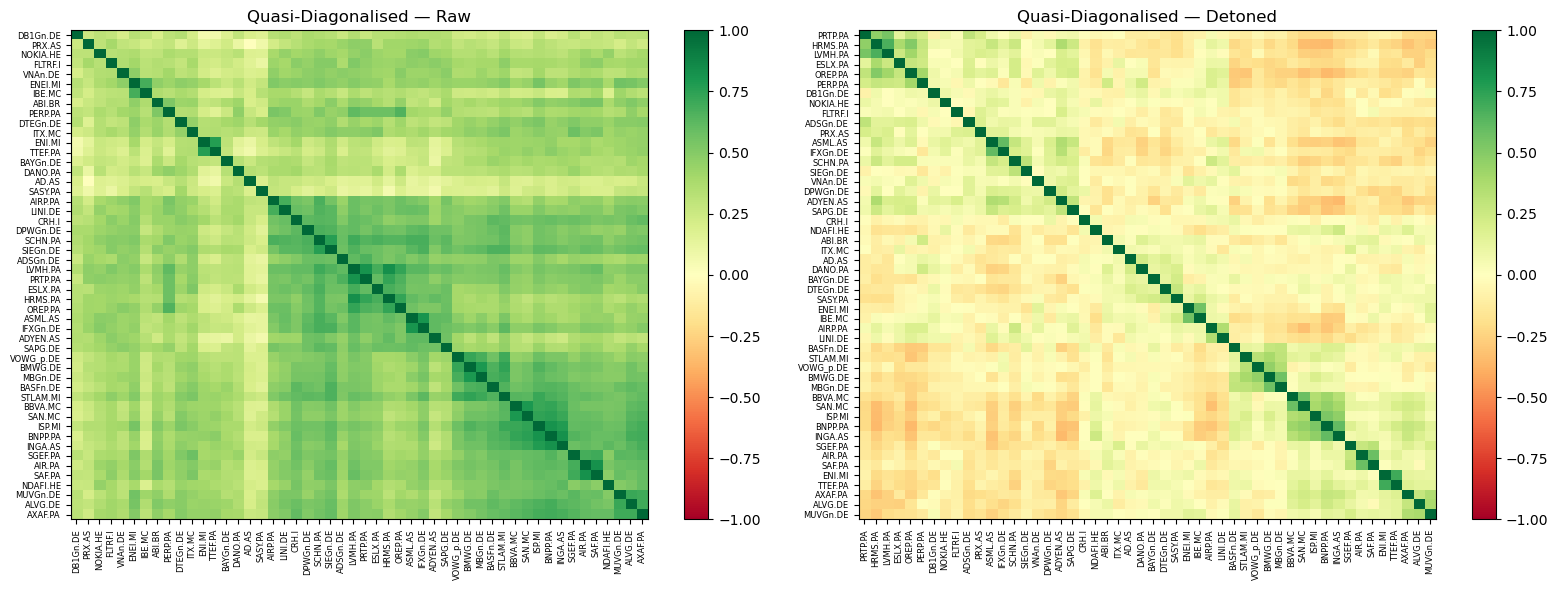

In [35]:
last_date = all_dates[-1]
sample_cov = covariances[last_date]["sample"]

corr_raw = covariance_to_correlation(sample_cov.values)
corr_detoned = detone(corr_raw, components_num=1)

dist_raw = correlation_to_hrp_distance(corr_raw)
dist_detoned = correlation_to_hrp_distance(corr_detoned)

link_raw = hierarchical_clustering(
    matrix=pd.DataFrame(dist_raw, index=sample_cov.index, columns=sample_cov.columns),
    linkage_method="ward",
    distance_metric="euclidean",
)

link_detoned = hierarchical_clustering(
    matrix=pd.DataFrame(dist_detoned, index=sample_cov.index, columns=sample_cov.columns),
    linkage_method="ward",
    distance_metric="euclidean",
)

order_raw = sch.leaves_list(link_raw.values)
order_detoned = sch.leaves_list(link_detoned.values)

corr_raw_df = pd.DataFrame(corr_raw, index=sample_cov.index, columns=sample_cov.columns)
corr_detoned_df = pd.DataFrame(corr_detoned, index=sample_cov.index, columns=sample_cov.columns)

quasi_raw = corr_raw_df.iloc[order_raw, order_raw]
quasi_detoned = corr_detoned_df.iloc[order_detoned, order_detoned]


# 1) DENDROGRAMS

fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))

sch.dendrogram(
    link_raw.values,
    labels=sample_cov.index.tolist(),
    ax=axes1[0],
    color_threshold=0,
    leaf_rotation=90
)
axes1[0].set_title(f"Dendrogram — Raw Correlation — {last_date}")

sch.dendrogram(
    link_detoned.values,
    labels=sample_cov.index.tolist(),
    ax=axes1[1],
    color_threshold=0,
    leaf_rotation=90
)
axes1[1].set_title(f"Dendrogram — Detoned Correlation — {last_date}")

plt.tight_layout()
fig1.savefig("fig_detoning_dendrograms.png", dpi=300, bbox_inches="tight")
plt.show()

# 2) QUASI-DIAGONALISED MATRICES

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

im0 = axes2[0].imshow(quasi_raw.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
axes2[0].set_title("Quasi-Diagonalised — Raw")
axes2[0].set_xticks(range(len(quasi_raw)))
axes2[0].set_xticklabels(quasi_raw.columns, rotation=90, fontsize=6)
axes2[0].set_yticks(range(len(quasi_raw)))
axes2[0].set_yticklabels(quasi_raw.index, fontsize=6)
fig2.colorbar(im0, ax=axes2[0])

im1 = axes2[1].imshow(quasi_detoned.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
axes2[1].set_title("Quasi-Diagonalised — Detoned")
axes2[1].set_xticks(range(len(quasi_detoned)))
axes2[1].set_xticklabels(quasi_detoned.columns, rotation=90, fontsize=6)
axes2[1].set_yticks(range(len(quasi_detoned)))
axes2[1].set_yticklabels(quasi_detoned.index, fontsize=6)
fig2.colorbar(im1, ax=axes2[1])

plt.tight_layout()
fig2.savefig("fig_detoning_quasidiag.png", dpi=300, bbox_inches="tight")
plt.show()


### 2.b Generic Hierarchical Risk Parity Procedure

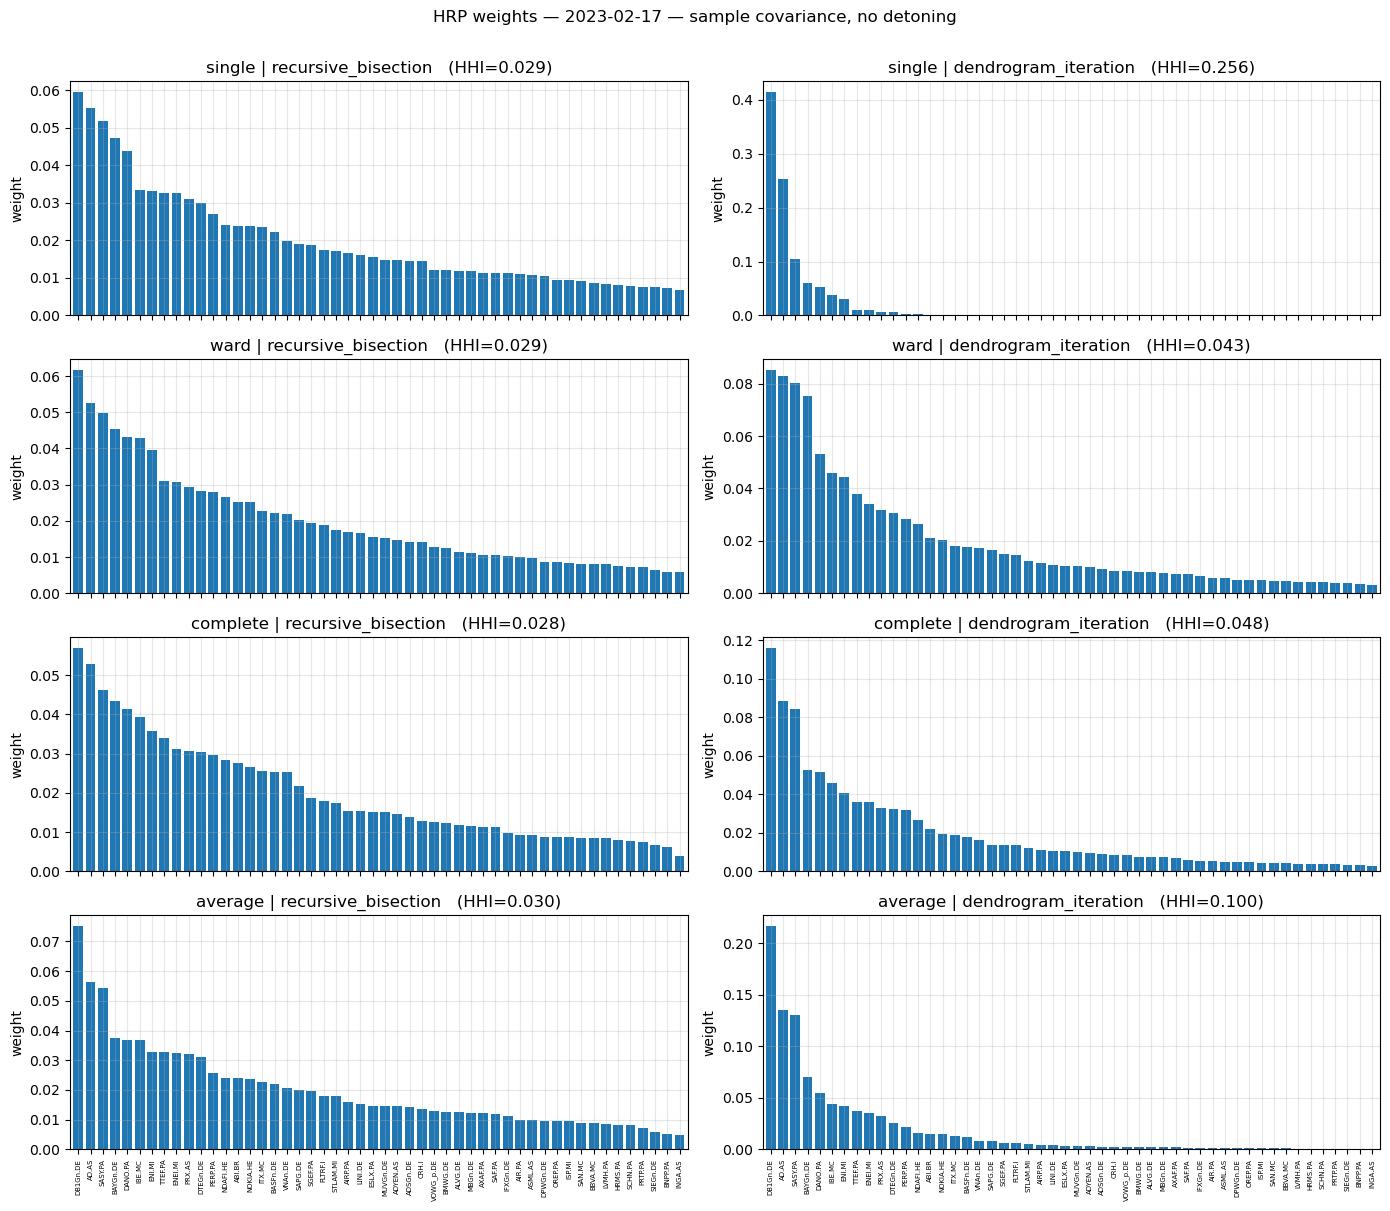

In [24]:
# 2.b — Demonstrate the generic HRP implementation across linkage and allocator
last_date = all_dates[-1]
sample_cov = covariances[last_date]["sample"]

LINK_GRID_2B = ["single", "ward", "complete", "average"]
ALLOC_GRID_2B = {
    "recursive_bisection": recursive_bisection,
    "dendrogram_iteration": dendrogram_iteration,
}

fig, axes = plt.subplots(
    len(LINK_GRID_2B), len(ALLOC_GRID_2B), figsize=(14, 12), sharex=True
)

for i, link in enumerate(LINK_GRID_2B):
    for j, (alloc_name, alloc) in enumerate(ALLOC_GRID_2B.items()):
        weights = hierarchical_risk_parity(
            covariance=sample_cov,
            linkage_method=link,
            distance_metric="euclidean",
            cluster_traverser=alloc,
            perform_detoning=False,
        )
        ax = axes[i, j]
        weights.sort_values(ascending=False).plot(
            kind="bar", ax=ax, color="C0", width=0.8
        )
        ax.set_title(
            f"{link} | {alloc_name}   (HHI={float((weights ** 2).sum()):.3f})"
        )
        ax.set_ylabel("weight")
        ax.tick_params(axis="x", labelsize=5, rotation=90)
        ax.grid(alpha=0.3)

plt.suptitle(
    f"HRP weights — {last_date} — sample covariance, no detoning", y=1.005
)
plt.tight_layout()
plt.show()

### 2.c Cluster stability across rebalances (Rand index)

We measure how stable the clustering is between consecutive rebalances via the Rand index. A value close to 1 means the partition into $k$ clusters changes little month-to-month.


/Users/giacomocosta/Desktop/Assignment 4b Locatelli Soldati/utilities/hierarchical_clustering.py:31: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/giacomocosta/Desktop/Assignment 4b Locatelli Soldati/utilities/hierarchical_clustering.py:31: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/giacomocosta/Desktop/Assignment 4b Locatelli Soldati/utilities/hierarchical_clustering.py:31: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/giacomocosta/Desktop/Assignment 4b Locatelli Soldati/utilities/hierarchical_clustering.py:31: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  li

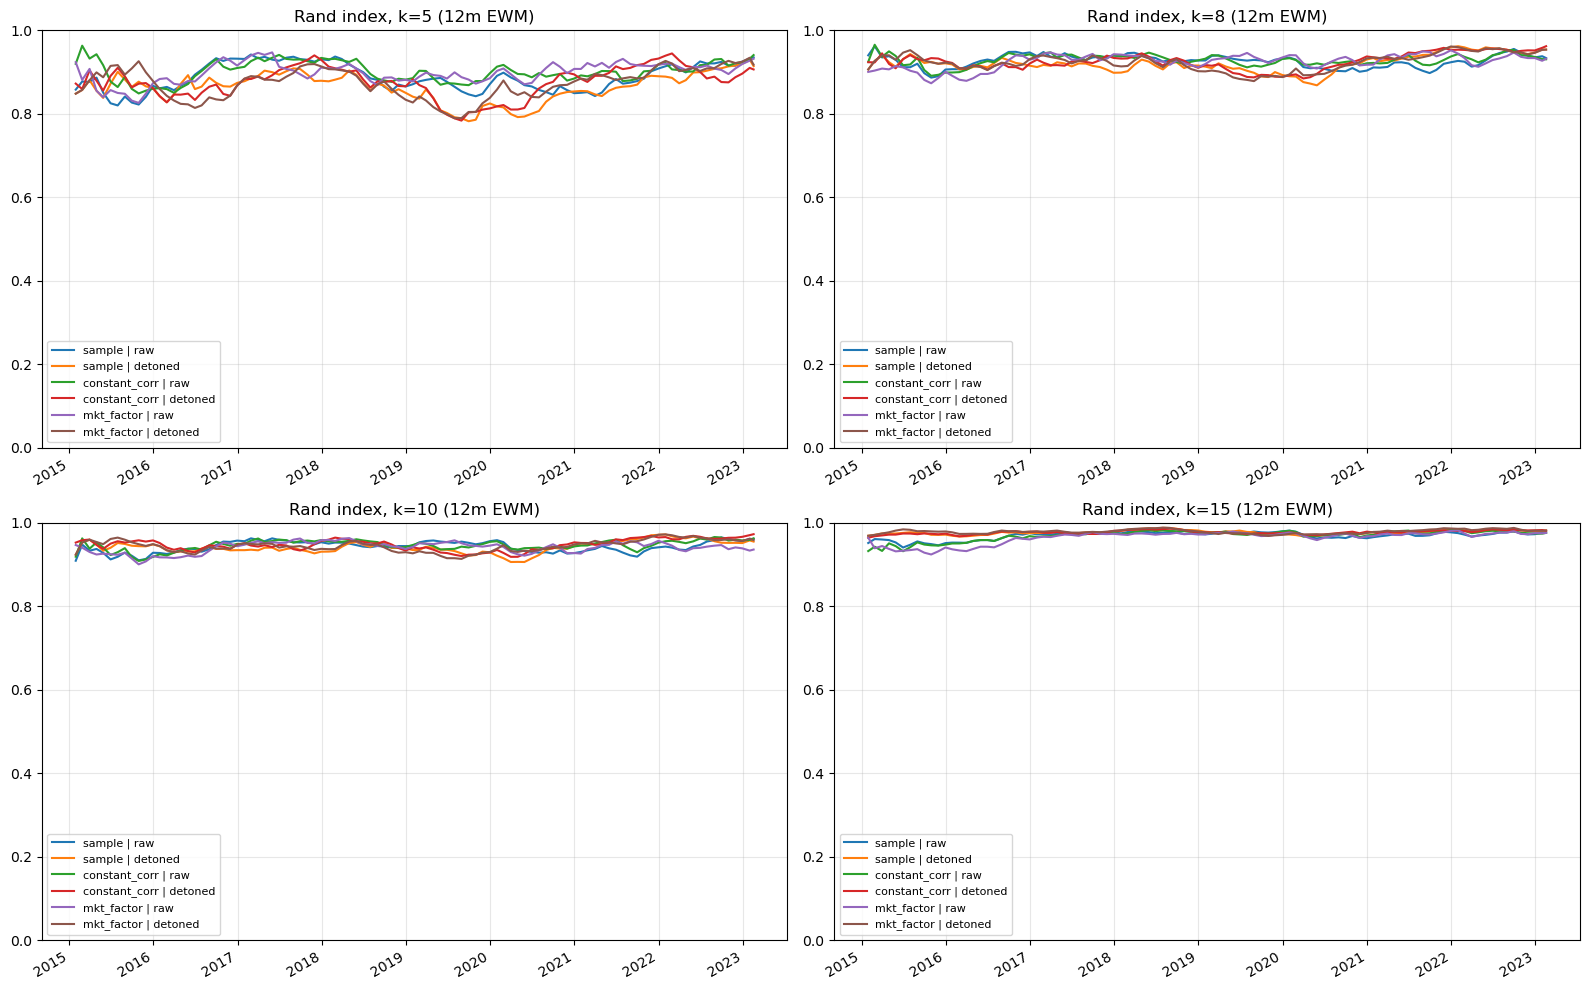

,k=10 mean Rand
sample | raw,0.944489
sample | detoned,0.942694
constant_corr | raw,0.948044
constant_corr | detoned,0.949141
mkt_factor | raw,0.941455
mkt_factor | detoned,0.945431


In [25]:
LINKAGE_METHOD = "ward"
DIST_METRIC = "euclidean"
N_CLUSTERS_GRID = [5, 8, 10, 15]
N_CLUSTERS_FOCUS = 10
COV_KEYS = ["sample", "constant_corr", "mkt_factor"]
DETONE_KEYS = [False, True]


linkages = {(c, d): {} for c in COV_KEYS for d in DETONE_KEYS}
clusters = {(c, d, k): {} for c in COV_KEYS for d in DETONE_KEYS for k in N_CLUSTERS_GRID}

for reb in all_dates:
    for cov_key in COV_KEYS:
        cov = covariances[reb][cov_key]
        for detone_flag in DETONE_KEYS:
            corr = covariance_to_correlation(cov.values)
            if detone_flag:
                corr = detone(corr, components_num=1)
            distance = correlation_to_hrp_distance(corr)
            link = hierarchical_clustering(
                matrix=pd.DataFrame(distance, index=cov.index, columns=cov.columns),
                linkage_method=LINKAGE_METHOD,
                distance_metric=DIST_METRIC,
            )
            linkages[(cov_key, detone_flag)][reb] = link
            for n_clusters in N_CLUSTERS_GRID:
                clusters[(cov_key, detone_flag, n_clusters)][reb] = pd.Series(
                    sch.cut_tree(link.values, n_clusters=n_clusters).flatten(),
                    index=cov.index,
                )

# Rand index between consecutive rebalances on the common universe
rand_index_series = {}
for cov_key in COV_KEYS:
    for detone_flag in DETONE_KEYS:
        for k in N_CLUSTERS_GRID:
            scores = {}
            sorted_dates = sorted(clusters[(cov_key, detone_flag, k)].keys())
            for prev, curr in zip(sorted_dates, sorted_dates[1:]):
                prev_cl = clusters[(cov_key, detone_flag, k)][prev]
                curr_cl = clusters[(cov_key, detone_flag, k)][curr]
                common = prev_cl.index.intersection(curr_cl.index)
                if len(common) >= 2:
                    scores[curr] = rand_score(prev_cl[common].values, curr_cl[common].values)
            ts = pd.Series(scores).sort_index()
            ts.index = pd.to_datetime(ts.index)
            rand_index_series[(cov_key, detone_flag, k)] = ts

# 12m EWM smoothed plot, one panel per k
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, k in enumerate(N_CLUSTERS_GRID):
    ax = axes[i // 2, i % 2]
    for cov_key in COV_KEYS:
        for detone_flag in DETONE_KEYS:
            ts = rand_index_series[(cov_key, detone_flag, k)]
            label = f"{cov_key} | {'detoned' if detone_flag else 'raw'}"
            ts.ewm(span=12).mean().plot(ax=ax, label=label)
    ax.set_title(f"Rand index, k={k} (12m EWM)")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Cross-section average per variant for the focus k
focus_table = pd.DataFrame({
    f"{c} | {'detoned' if d else 'raw'}":
        rand_index_series[(c, d, N_CLUSTERS_FOCUS)].mean()
    for c in COV_KEYS for d in DETONE_KEYS
}, index=[f"k={N_CLUSTERS_FOCUS} mean Rand"])
focus_table.T

### 2.d Sensitivity of HRP weights — clustering vs. allocation traversal


In [26]:
LINK_GRID = ["single", "ward", "complete", "average"]

ALLOC_GRID = {
    "recursive_bisection": recursive_bisection,
    "dendrogram_iteration": dendrogram_iteration,
}

def compute_one_variant(cov_key, link, alloc_name, d):
    alloc = ALLOC_GRID[alloc_name]

    weights_list = []
    index = []

    for reb in all_dates:
        cov = covariances[reb][cov_key]

        w = hierarchical_risk_parity(
            covariance=cov,
            linkage_method=link,
            distance_metric="euclidean",
            cluster_traverser=alloc,
            perform_detoning=d,
        )

        weights_list.append(w)
        index.append(reb)

    weights_df = pd.DataFrame(weights_list, index=index).fillna(0.0)

    return (cov_key, link, alloc_name, d), weights_df


tasks = list(product(COV_KEYS, LINK_GRID, ALLOC_GRID.keys(), DETONE_KEYS))

results = Parallel(n_jobs=-1, verbose=10)(
    delayed(compute_one_variant)(cov_key, link, alloc_name, d)
    for cov_key, link, alloc_name, d in tasks
)

hrp_grid = dict(results)
# Summary statistics: mean turnover and mean HHI per variant
def mean_turnover(weights_df: pd.DataFrame) -> float:
    return weights_df.diff().abs().sum(axis=1).iloc[1:].mean()

def mean_hhi(weights_df: pd.DataFrame) -> float:
    return (weights_df ** 2).sum(axis=1).mean()

records = []
for (cov_key, link, alloc_name, d), weights_df in hrp_grid.items():
    records.append({
        "estimator":    cov_key,
        "linkage":      link,
        "allocator":    alloc_name,
        "detoning":     d,
        "mean_turnover": mean_turnover(weights_df),
        "mean_HHI":      mean_hhi(weights_df),
    })

hrp_summary = pd.DataFrame(records).sort_values(["linkage", "allocator", "estimator", "detoning"])
hrp_summary

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


/Users/giacomocosta/Desktop/Assignment 4b Locatelli Soldati/utilities/hierarchical_clustering.py:31: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/giacomocosta/Desktop/Assignment 4b Locatelli Soldati/utilities/hierarchical_clustering.py:31: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/giacomocosta/Desktop/Assignment 4b Locatelli Soldati/utilities/hierarchical_clustering.py:31: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/giacomocosta/Desktop/Assignment 4b Locatelli Soldati/utilities/hierarchical_clustering.py:31: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  li

,estimator,linkage,allocator,detoning,mean_turnover,mean_HHI
30,constant_corr,average,dendrogram_iteration,False,0.269025,0.104589
31,constant_corr,average,dendrogram_iteration,True,0.329170,0.039825
46,mkt_factor,average,dendrogram_iteration,False,0.260833,0.113033
47,mkt_factor,average,dendrogram_iteration,True,0.336699,0.039738
14,sample,average,dendrogram_iteration,False,0.276361,0.102478
15,sample,average,dendrogram_iteration,True,0.354935,0.039574
28,constant_corr,average,recursive_bisection,False,0.212607,0.026585
29,constant_corr,average,recursive_bisection,True,0.212283,0.026077
44,mkt_factor,average,recursive_bisection,False,0.211398,0.027326
45,mkt_factor,average,recursive_bisection,True,0.207964,0.026503


## Part III — Connecting the Dots


### 3.a ERC vs HRP — Robustness Against Estimator Choice

In [29]:
def avg_l1_across_estimators(weights_dict: dict[str, pd.DataFrame]) -> float:
    """Mean over all date-level L1 distances and over all estimator pairs."""
    estimators = list(weights_dict.keys())
    pairwise_means = []
    for i in range(len(estimators)):
        for j in range(i + 1, len(estimators)):
            df1 = weights_dict[estimators[i]]
            df2 = weights_dict[estimators[j]]
            common_dates  = df1.index.intersection(df2.index)
            common_assets = df1.columns.union(df2.columns)
            d1 = df1.reindex(index=common_dates, columns=common_assets, fill_value=0.0)
            d2 = df2.reindex(index=common_dates, columns=common_assets, fill_value=0.0)
            pairwise_means.append((d1 - d2).abs().sum(axis=1).mean())
    return float(np.mean(pairwise_means))

# Select representative HRP strategy across estimators.
# The estimator is not part of the HRP strategy selection for Exercise 3.a,
# because the goal is precisely to test robustness to the estimator.

hrp_rep_summary = (
    hrp_summary
    .groupby(["linkage", "allocator", "detoning"], as_index=False)
    .agg({
        "mean_turnover": "mean",
        "mean_HHI": "mean",
    })
)

hrp_rep_candidates = hrp_rep_summary.copy()

hrp_rep_candidates["turnover_score"] = (
    hrp_rep_candidates["mean_turnover"]
    - hrp_rep_candidates["mean_turnover"].min()
) / (
    hrp_rep_candidates["mean_turnover"].max()
    - hrp_rep_candidates["mean_turnover"].min()
)

hrp_rep_candidates["HHI_score"] = (
    hrp_rep_candidates["mean_HHI"]
    - hrp_rep_candidates["mean_HHI"].min()
) / (
    hrp_rep_candidates["mean_HHI"].max()
    - hrp_rep_candidates["mean_HHI"].min()
)

hrp_rep_candidates["combined_score"] = (
    hrp_rep_candidates["turnover_score"]
    + hrp_rep_candidates["HHI_score"]
)

representative_hrp = (
    hrp_rep_candidates
    .sort_values("combined_score")
    .iloc[0]
)

HRP_LINK = representative_hrp["linkage"]
HRP_ALLOC = representative_hrp["allocator"]
HRP_DETONE = representative_hrp["detoning"]

print("Selected representative HRP strategy:")
display(representative_hrp)

erc_by_estimator = {
    name: pd.DataFrame.from_dict(d, orient="index").fillna(0.0)
    for name, d in erc_portfolios.items()
}
hrp_by_estimator = {
    cov_key: hrp_grid[(cov_key, HRP_LINK, HRP_ALLOC, HRP_DETONE)]
    for cov_key in COV_KEYS
}

erc_l1 = avg_l1_across_estimators(erc_by_estimator)
hrp_l1 = avg_l1_across_estimators(hrp_by_estimator)

robustness = pd.Series(
    {"ERC": erc_l1, f"HRP ({HRP_LINK}, {HRP_ALLOC}, detone={HRP_DETONE})": hrp_l1},
    name="avg L1 weight distance across estimators",
)
robustness.to_frame()

Selected representative HRP strategy:


linkage                        single
allocator         recursive_bisection
detoning                        False
mean_turnover                0.197562
mean_HHI                       0.0275
turnover_score                    0.0
HHI_score                    0.007058
combined_score               0.007058
Name: 10, dtype: object

,avg L1 weight distance across estimators
ERC,0.022083
"HRP (single, recursive_bisection, detone=False)",0.178940


### 3.b ERC vs HRP — performance, vol, drawdown, turnover


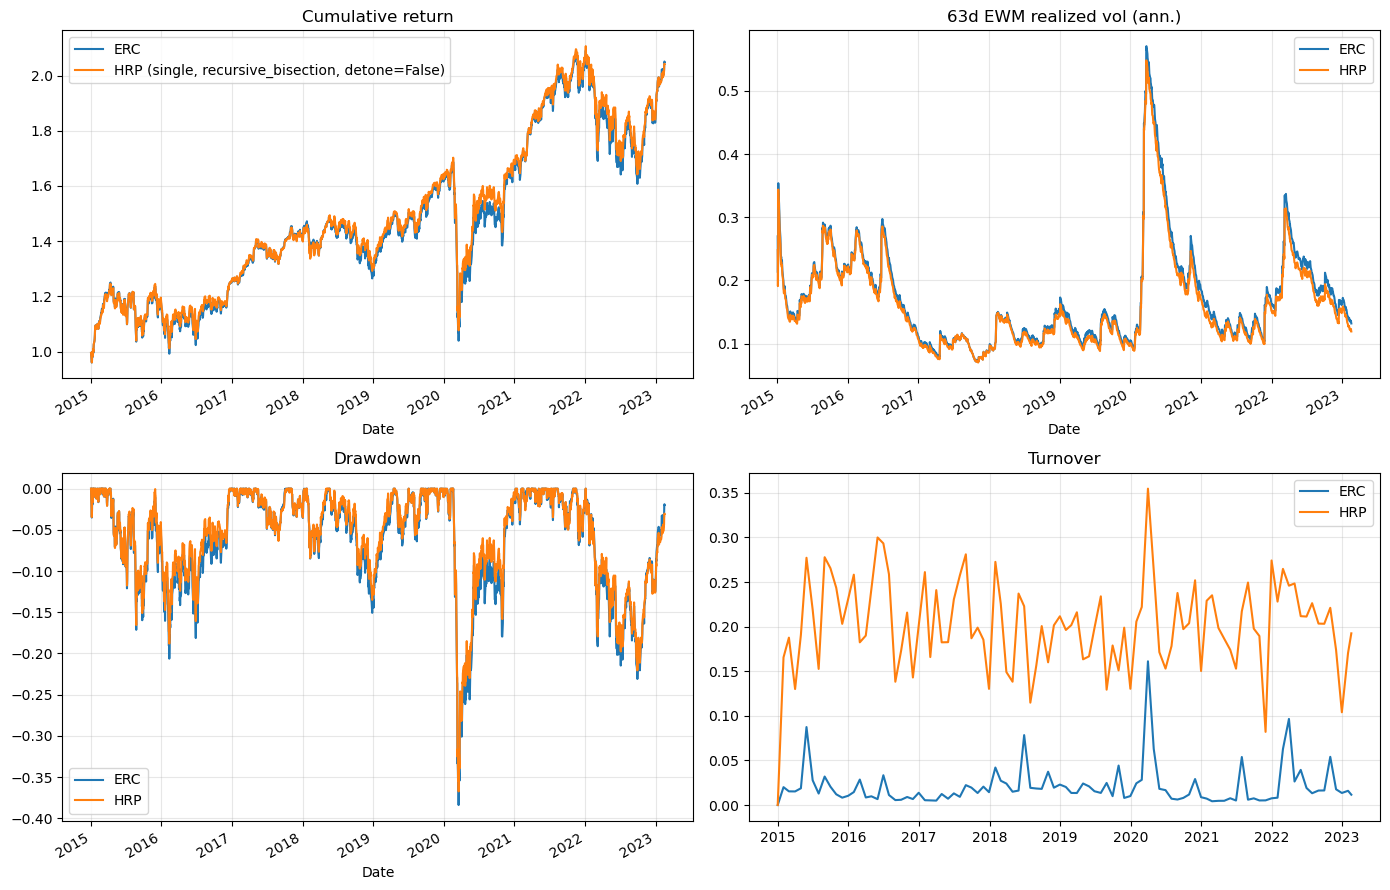

,ERC,HRP
CAGR,0.092293,0.091828
Ann. vol,0.187659,0.178423
Max drawdown,-0.383985,-0.367438
Mean turnover,0.020716,0.201843


In [33]:
# Representative variants on the sample covariance estimator
erc_weights = erc_by_estimator["sample"]
hrp_weights = hrp_by_estimator["sample"]

erc_curve   = backtest(erc_weights,   performance)
hrp_curve   = backtest(hrp_weights,   performance)
erc_returns = portfolio_returns(erc_weights, performance)
hrp_returns = portfolio_returns(hrp_weights, performance)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
erc_curve.plot(ax=ax, label="ERC")
hrp_curve.plot(ax=ax, label=f"HRP ({HRP_LINK}, {HRP_ALLOC}, detone={HRP_DETONE})")
ax.set_title("Cumulative return"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
(erc_returns.ewm(span=63).std() * np.sqrt(trading_days)).plot(ax=ax, label="ERC")
(hrp_returns.ewm(span=63).std() * np.sqrt(trading_days)).plot(ax=ax, label="HRP")
ax.set_title("63d EWM realized vol (ann.)"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
(erc_curve / erc_curve.cummax() - 1.0).plot(ax=ax, label="ERC")
(hrp_curve / hrp_curve.cummax() - 1.0).plot(ax=ax, label="HRP")
ax.set_title("Drawdown"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 1]
erc_weights.diff().abs().sum(axis=1).plot(ax=ax, label="ERC")
hrp_weights.diff().abs().sum(axis=1).plot(ax=ax, label="HRP")
ax.set_title("Turnover"); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Compact summary table
def annualized_vol(r: pd.Series) -> float:
    return float(r.std() * np.sqrt(trading_days))

def cagr(curve: pd.Series) -> float:
    n_years = (curve.index[-1] - curve.index[0]).days / 365.25
    return float(curve.iloc[-1] ** (1 / n_years) - 1)

def max_drawdown(curve: pd.Series) -> float:
    return float((curve / curve.cummax() - 1.0).min())

summary = pd.DataFrame({
    "ERC": [
        cagr(erc_curve),
        annualized_vol(erc_returns),
        max_drawdown(erc_curve),
        erc_weights.diff().abs().sum(axis=1).mean(),
    ],
    "HRP": [
        cagr(hrp_curve),
        annualized_vol(hrp_returns),
        max_drawdown(hrp_curve),
        hrp_weights.diff().abs().sum(axis=1).mean(),
    ],
}, index=["CAGR", "Ann. vol", "Max drawdown", "Mean turnover"])
summary